In [3]:
# ===============================================
# Code Block 1 — Imports, Paths, Load Data
# ==============================================


import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import entropy

IN_DIR  = "../data/processed"
OUT_DIR = "../data/final"
os.makedirs(OUT_DIR, exist_ok=True)

MUNI_FILE     = os.path.join(IN_DIR, "municipality_features_with_outliers.csv")
CASE_HYB_FILE = os.path.join(IN_DIR, "case_hybrid_scores.csv")
RES_HYB_FILE  = os.path.join(IN_DIR, "resource_hybrid_scores.csv")
EVENT_FILE    = os.path.join(IN_DIR, "event_scores.csv")

OUT_FILE      = os.path.join(OUT_DIR, "hybrid_performance_model.csv")

# Load
muni_df = pd.read_csv(MUNI_FILE, low_memory=False)
case_hyb = pd.read_csv(CASE_HYB_FILE, low_memory=False)
res_hyb = pd.read_csv(RES_HYB_FILE, low_memory=False)
event_df = pd.read_csv(EVENT_FILE, low_memory=False)

print("Loaded:")
print("municipalities:", muni_df.shape)
print("case hybrid:", case_hyb.shape)
print("resource hybrid:", res_hyb.shape)
print("event scores:", event_df.shape)


Loaded:
municipalities: (5, 28)
case hybrid: (3183, 4)
resource hybrid: (64, 4)
event scores: (262628, 13)


In [4]:
# ===============================================
# Code Block 2 — Validate Required Columns
# ==============================================

# Municipality performance index must exist
if "performance_index" not in muni_df.columns:
    raise KeyError("Municipality file missing 'performance_index'")

required_case_cols = ["case_id", "municipality", "case_hybrid_score"]
if any(c not in case_hyb.columns for c in required_case_cols):
    raise KeyError("case_hybrid_scores missing required columns")

required_res_cols = ["resource", "municipality", "resource_hybrid_score"]
if any(c not in res_hyb.columns for c in required_res_cols):
    raise KeyError("resource_hybrid_scores missing required columns")

if "event_score" not in event_df.columns:
    raise KeyError("event_scores missing event_score")

print("Validation complete.")


Validation complete.


In [5]:
# ===============================================
# Code Block 3 — Aggregate Case & Resource & Event Scores per Municipality
# ==============================================


# Case → Municipality
case_muni_avg = (
    case_hyb.groupby("municipality")["case_hybrid_score"]
            .mean()
            .rename("avg_case_hybrid_score")
)

# Resource → Municipality
res_muni_avg = (
    res_hyb.groupby("municipality")["resource_hybrid_score"]
           .mean()
           .rename("avg_resource_hybrid_score")
)

# Event → Municipality
event_muni_avg = (
    event_df.groupby("case_id")["event_score"].mean()
            .reset_index()
            .merge(case_hyb[["case_id","municipality"]], on="case_id", how="left")
            .groupby("municipality")["event_score"]
            .mean()
            .rename("avg_event_score")
)

print("Aggregated subscores:")
display(pd.concat([case_muni_avg, res_muni_avg, event_muni_avg], axis=1).head())


Aggregated subscores:


,avg_case_hybrid_score,avg_resource_hybrid_score,avg_event_score
municipality,,,
BPIC15_1,0.695023,0.403762,0.707886
BPIC15_2,0.633748,0.371000,0.715545
BPIC15_3,0.687735,0.398300,0.716560
BPIC15_4,0.683254,0.473111,0.703309
BPIC15_5,0.692427,0.550000,0.709184


In [6]:
# ===============================================
# Code Block 4 — Build Unified Municipality Table
# ==============================================


muni = muni_df.set_index("municipality").copy()

# Add subscores
muni["avg_case_hybrid_score"]     = case_muni_avg
muni["avg_resource_hybrid_score"] = res_muni_avg
muni["avg_event_score"]           = event_muni_avg

# Outlier penalty
if "muni_outlier" in muni_df.columns:
    outliers = muni_df.set_index("municipality")["muni_outlier"]
    muni["outlier_penalty_muni"] = outliers.astype(float)
else:
    muni["outlier_penalty_muni"] = 0.0

# Fill missing with medians
muni = muni.fillna(muni.median(numeric_only=True))

print("Unified municipality table:")
display(muni.head())


Unified municipality table:


,n_cases,avg_cycle_hours,avg_wait_hours,avg_processing_hours,avg_rework,avg_cost,std_cycle_hours,variant_complexity,n_unique_variants,overdue_rate,...,avg_handover_out_norm,handovers_per_case_norm,performance_index_raw,performance_index,rank,muni_outlier,avg_case_hybrid_score,avg_resource_hybrid_score,avg_event_score,outlier_penalty_muni
municipality,,,,,,,,,,,,,,,,,,,,,
BPIC15_1,810,2346.385508,2346.385508,0.0,3.541975,104027.618765,2863.190953,44.241975,796,0.0,...,0.000000,0.0,0.171827,0.828173,2,False,0.695023,0.403762,0.707886,0.0
BPIC15_2,310,3770.189789,3770.189789,0.0,4.164516,97524.171404,3248.651639,55.122581,309,0.0,...,1.000000,0.0,0.600342,0.399658,4,False,0.633748,0.371000,0.715545,0.0
BPIC15_3,804,1724.267544,1724.267544,0.0,3.767413,151821.381975,2524.220728,43.584577,769,0.0,...,0.175149,0.0,0.047156,0.952844,1,False,0.687735,0.398300,0.716560,0.0
BPIC15_4,622,2932.718776,2932.718776,0.0,185.311897,310319.419781,3373.633607,228.004823,618,0.0,...,0.591659,0.0,0.604448,0.395552,5,True,0.683254,0.473111,0.703309,1.0
BPIC15_5,637,2552.882832,2552.882832,0.0,4.029827,144841.536092,2853.616028,51.558870,635,0.0,...,0.844878,0.0,0.298621,0.701379,3,False,0.692427,0.550000,0.709184,0.0


In [7]:
# ===============================================
# Code Block 5A - Normalize Features (Metrics where lower = worse)
# ==============================================


lower_is_better = [
    "avg_cycle_hours",
    "avg_wait_hours",
    "avg_cost",
    "avg_rework",
    "avg_handover_out",
    "handovers_per_case",
    "outlier_penalty_muni"
]


In [8]:
# ===============================================
# Code Block 5B - Normalize Features (Metrics where higher = better)
# ==============================================


higher_is_better = [
    "performance_index",
    "avg_case_hybrid_score",
    "avg_resource_hybrid_score",
    "avg_event_score",
    "n_resources"
]


In [9]:
# ===============================================
# Code Block 5C — Normalize using MinMax
# ==============================================


feat = muni[lower_is_better + higher_is_better].copy()
feat = feat.apply(pd.to_numeric, errors="coerce")
feat = feat.replace([np.inf, -np.inf], np.nan)
feat = feat.fillna(feat.median())

mm = MinMaxScaler()
feat_scaled = pd.DataFrame(
    mm.fit_transform(feat),
    index=feat.index,
    columns=feat.columns
)

# Invert lower metrics
for col in lower_is_better:
    feat_scaled[col] = 1.0 - feat_scaled[col]

muni_norm = feat_scaled.copy()

print("Normalized muni matrix:")
display(muni_norm.head())


Normalized muni matrix:


,avg_cycle_hours,avg_wait_hours,avg_cost,avg_rework,avg_handover_out,handovers_per_case,outlier_penalty_muni,performance_index,avg_case_hybrid_score,avg_resource_hybrid_score,avg_event_score,n_resources
municipality,,,,,,,,,,,,
BPIC15_1,6.959230e-01,6.959230e-01,0.969438,1.000000,1.000000,1.0,1.0,0.776292,1.000000,0.183027,0.345429,1.000000
BPIC15_2,1.110223e-16,1.110223e-16,1.000000,0.996575,0.000000,1.0,1.0,0.007367,0.000000,0.000000,0.923431,0.000000
BPIC15_3,1.000000e+00,1.000000e+00,0.744838,0.998760,0.824851,1.0,1.0,1.000000,0.881055,0.152514,1.000000,0.933333
BPIC15_4,4.093367e-01,4.093367e-01,0.000000,0.000000,0.408341,1.0,0.0,0.000000,0.807925,0.570453,0.000000,0.200000
BPIC15_5,5.949918e-01,5.949918e-01,0.777639,0.997316,0.155122,1.0,1.0,0.548773,0.957626,1.000000,0.443350,0.133333


In [10]:
# ===============================================
# Code Block 6 — PCA + Entropy Weight Calculation
# ==============================================


# Drop zero-variance columns
const_cols = [c for c in muni_norm.columns if muni_norm[c].std() == 0]
if const_cols:
    print("Dropping constant columns:", const_cols)
    muni_norm = muni_norm.drop(columns=const_cols)

# PCA
scaler = StandardScaler()
Xpca = scaler.fit_transform(muni_norm)

pca = PCA(n_components=1, random_state=42)
pca.fit(Xpca)

w_pca = np.abs(pca.components_[0])
w_pca = w_pca / w_pca.sum()

# Entropy
vals = MinMaxScaler().fit_transform(muni_norm)
P = vals / (vals.sum(axis=0) + 1e-12)
E = np.array([entropy(P[:,i]) for i in range(P.shape[1])])
d = 1 - E / np.log(len(P))
w_entropy = d / d.sum()

# Final combined weights
w_comb = (w_pca + w_entropy) / 2.0
w_comb = w_comb / w_comb.sum()

muni_weights = dict(zip(muni_norm.columns, w_comb))

print("Final learned municipality weights:")
for k,v in muni_weights.items():
    print(f"{k}: {v:.3f}")


Dropping constant columns: ['handovers_per_case']
Final learned municipality weights:
avg_cycle_hours: 0.099
avg_wait_hours: 0.099
avg_cost: 0.061
avg_rework: 0.070
avg_handover_out: 0.111
outlier_penalty_muni: 0.070
performance_index: 0.140
avg_case_hybrid_score: 0.074
avg_resource_hybrid_score: 0.078
avg_event_score: 0.066
n_resources: 0.132


In [11]:
# ===============================================
# Code Block 7 — Compute Final Hybrid Municipality Score
# ==============================================


raw = np.zeros(len(muni_norm))
for col in muni_norm.columns:
    raw += muni_norm[col].values * muni_weights[col]

# Normalize
hyb = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)

muni["hybrid_score_raw"] = raw
muni["hybrid_score"]     = np.round(hyb, 3)
muni["rank"]             = muni["hybrid_score"].rank(ascending=False).astype(int)

print("Final hybrid municipality scores:")
display(muni[["hybrid_score_raw", "hybrid_score", "rank"]].sort_values("rank").head())


Final hybrid municipality scores:


,hybrid_score_raw,hybrid_score,rank
municipality,,,
BPIC15_3,0.881339,1.000,1
BPIC15_1,0.799920,0.870,2
BPIC15_5,0.594616,0.541,3
BPIC15_2,0.262148,0.008,4
BPIC15_4,0.257190,0.000,5


In [12]:
# ===============================================
# Code Block 8 — Save Final Output
# ==============================================


final_df = muni.reset_index()
final_df.to_csv(OUT_FILE, index=False)

print("Saved final hybrid performance model:")
print(OUT_FILE)


Saved final hybrid performance model:
../data/final\hybrid_performance_model.csv


Original performance_index vs hybrid_score_raw:


,municipality,performance_index,hybrid_score_raw
0,BPIC15_1,0.828173,0.799920
1,BPIC15_2,0.399658,0.262148
2,BPIC15_3,0.952844,0.881339
3,BPIC15_4,0.395552,0.257190
4,BPIC15_5,0.701379,0.594616



Pearson r(performance_index, hybrid_score_raw) = 0.996


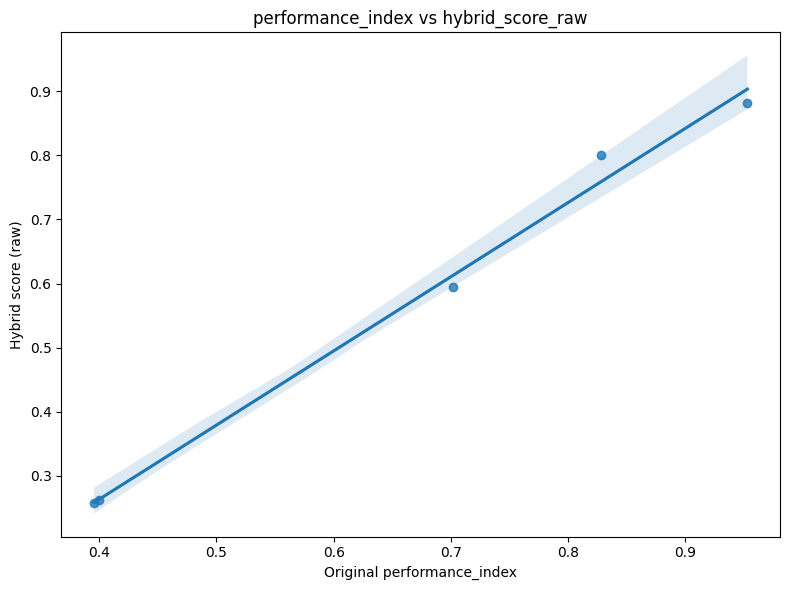

In [13]:
# ===============================================
# Visualization: performance_index vs hybrid_score_raw
# ===============================================
import matplotlib.pyplot as plt
import seaborn as sns

df_scores = muni.reset_index()[["municipality", "performance_index", "hybrid_score_raw"]]

# Optional: show table for reference
print("Original performance_index vs hybrid_score_raw:")
display(df_scores)

# Pearson correlation
r = df_scores["performance_index"].corr(df_scores["hybrid_score_raw"])
print(f"\nPearson r(performance_index, hybrid_score_raw) = {r:.3f}")

# Scatter + regression
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_scores,
    x="performance_index",
    y="hybrid_score_raw"
)
plt.xlabel("Original performance_index")
plt.ylabel("Hybrid score (raw)")
plt.title("performance_index vs hybrid_score_raw")
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def set_dashboard_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.dpi": 150,
        "axes.edgecolor": "#cccccc",
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
    })

def plot_metric_dashboard(df, metric_cols, titles=None, n_cols=4,
                          suptitle=None, x_axis_label="Index (sorted by metric)"):
    set_dashboard_style()

    n_metrics = len(metric_cols)
    n_rows = int(np.ceil(n_metrics / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3 * n_cols, 2.2 * n_rows),
        sharex=False,
        sharey=False,
    )
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(metric_cols):
        ax = axes[i]
        series = df[col].dropna().sort_values()
        x = np.arange(1, len(series) + 1)

        ax.plot(x, series.values, color="black", linewidth=1.0)
        ax.set_xlim(1, len(series))

        if titles is not None:
            ax.set_title(titles[i])
        else:
            ax.set_title(col.replace("_", " ").title())

        ax.ticklabel_format(axis="y", style="plain", useOffset=False)

        for spine in ["left", "bottom"]:
            ax.spines[spine].set_color("#cccccc")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    for j in range(n_metrics, len(axes)):
        axes[j].axis("off")

    for r in range(n_rows):
        for c in range(n_cols):
            idx = r * n_cols + c
            if idx >= n_metrics:
                continue
            ax = axes[idx]
            if r == n_rows - 1:
                ax.set_xlabel(x_axis_label)
            else:
                ax.set_xticklabels([])

    if suptitle is not None:
        fig.suptitle(suptitle, y=1.02, fontsize=11)

    fig.tight_layout()
    return fig, axes

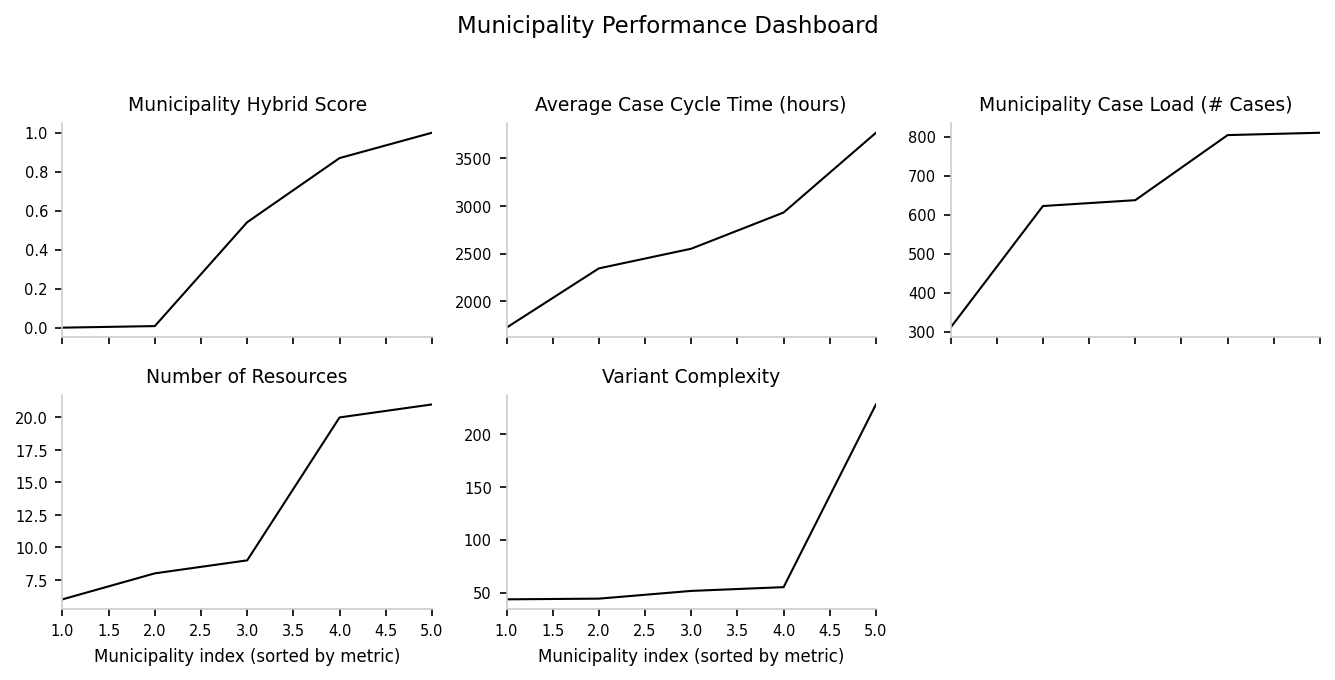

In [15]:
muni_metric_cols = [
    "hybrid_score",
    "avg_cycle_hours",
    "n_cases",
    "n_resources",
    "variant_complexity",
]

muni_metric_titles = [
    "Municipality Hybrid Score",
    "Average Case Cycle Time (hours)",
    "Municipality Case Load (# Cases)",
    "Number of Resources",
    "Variant Complexity",
]

fig_muni, axes_muni = plot_metric_dashboard(
    df=muni,
    metric_cols=muni_metric_cols,
    titles=muni_metric_titles,
    n_cols=3,
    suptitle="Municipality Performance Dashboard",
    x_axis_label="Municipality index (sorted by metric)",
)

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_weight_comparison(weight_data, weight_manual, title, rotation=45):
    """
    Side-by-side bar chart:
    - weight_data:  dict of data-driven weights (PCA+Entropy)
    - weight_manual: dict of standard/manual weights with the same keys
    """
    features = list(weight_data.keys())
    data_vals = [weight_data[f] for f in features]
    manual_vals = [weight_manual[f] for f in features]

    x = np.arange(len(features))
    width = 0.38

    fig, ax = plt.subplots(figsize=(1.6 * len(features), 4))

    # Standard/manual weights
    ax.bar(x - width/2, manual_vals, width,
           label="Standard weights", color="#cccccc", edgecolor="black", linewidth=0.7)
    # Data-driven weights
    ax.bar(x + width/2, data_vals, width,
           label="Data-driven (PCA+Entropy)", color="black", alpha=0.9)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Weight")
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=rotation, ha="right")

    # Minimalist axes, no grid
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax

Skipping features not present in muni_weights: ['handovers_per_case']


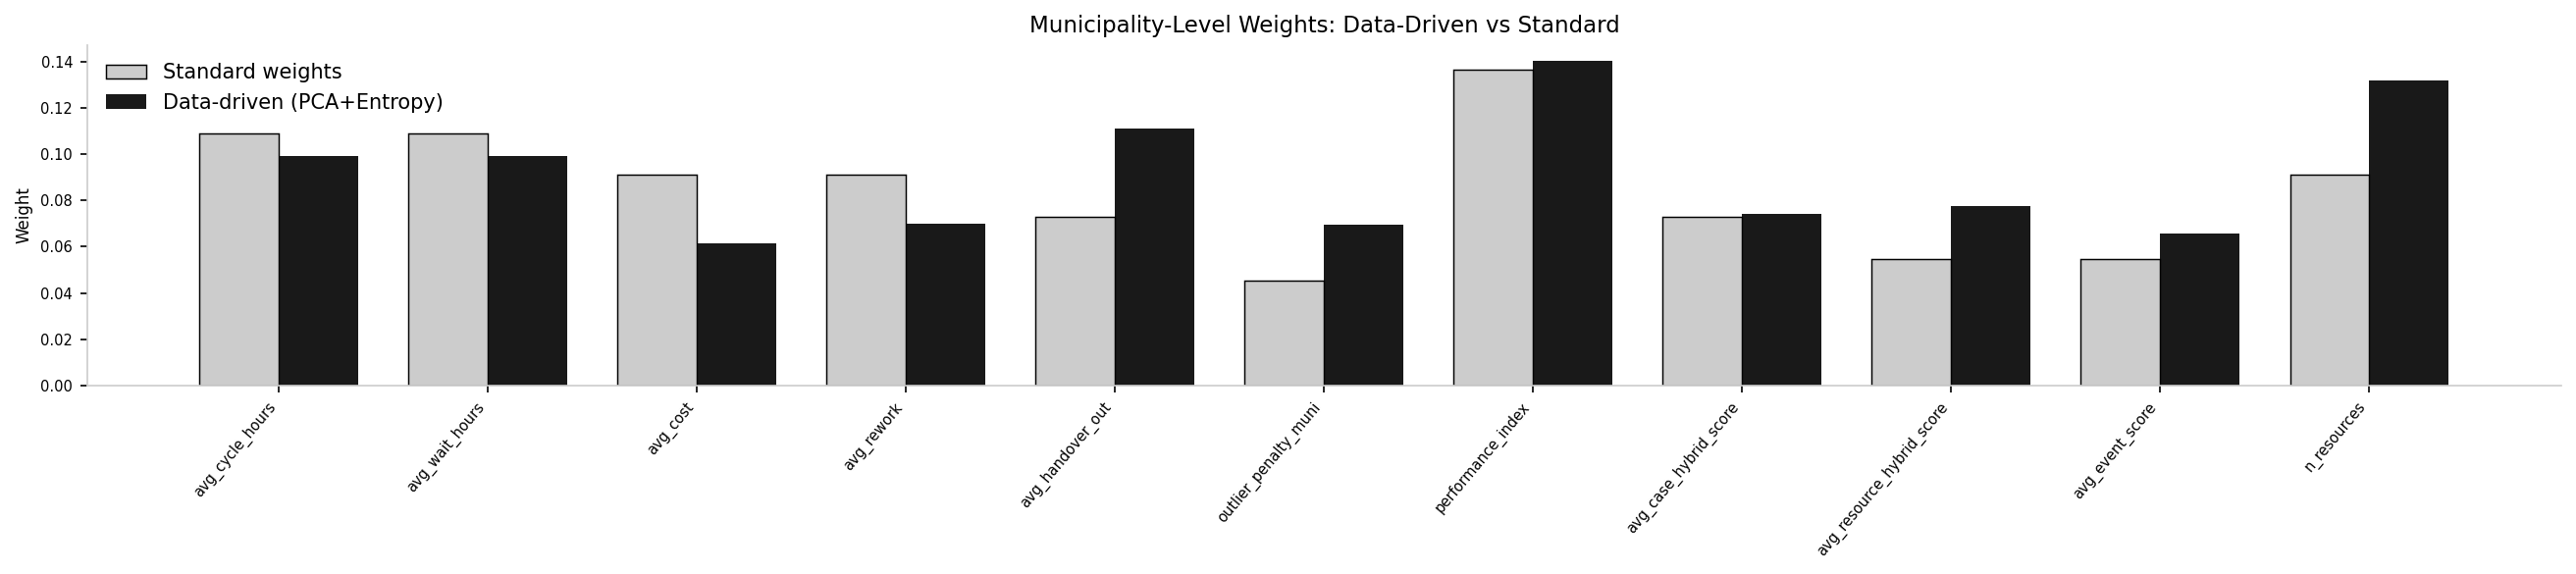

In [18]:
# ----- Standard / manual weights for municipality comparison -----
muni_weights_manual = {
    "avg_cycle_hours":            0.12,
    "avg_wait_hours":             0.12,
    "avg_cost":                   0.10,
    "avg_rework":                 0.10,
    "avg_handover_out":           0.08,
    "handovers_per_case":         0.08,
    "outlier_penalty_muni":       0.05,
    "performance_index":          0.15,
    "avg_case_hybrid_score":      0.08,
    "avg_resource_hybrid_score":  0.06,
    "avg_event_score":            0.06,
    "n_resources":                0.10,
}

total_manual_muni = sum(muni_weights_manual.values())
muni_weights_manual = {k: v / total_manual_muni for k, v in muni_weights_manual.items()}

# Use only features that exist in BOTH dictionaries
shared_features = [k for k in muni_weights_manual.keys() if k in muni_weights]

missing = [k for k in muni_weights_manual.keys() if k not in muni_weights]
if missing:
    print("Skipping features not present in muni_weights:", missing)

muni_weights_ordered = {k: muni_weights[k] for k in shared_features}
muni_weights_manual_used = {k: muni_weights_manual[k] for k in shared_features}

fig_muni_w, ax_muni_w = plot_weight_comparison(
    weight_data=muni_weights_ordered,
    weight_manual=muni_weights_manual_used,
    title="Municipality-Level Weights: Data-Driven vs Standard",
    rotation=50,
)

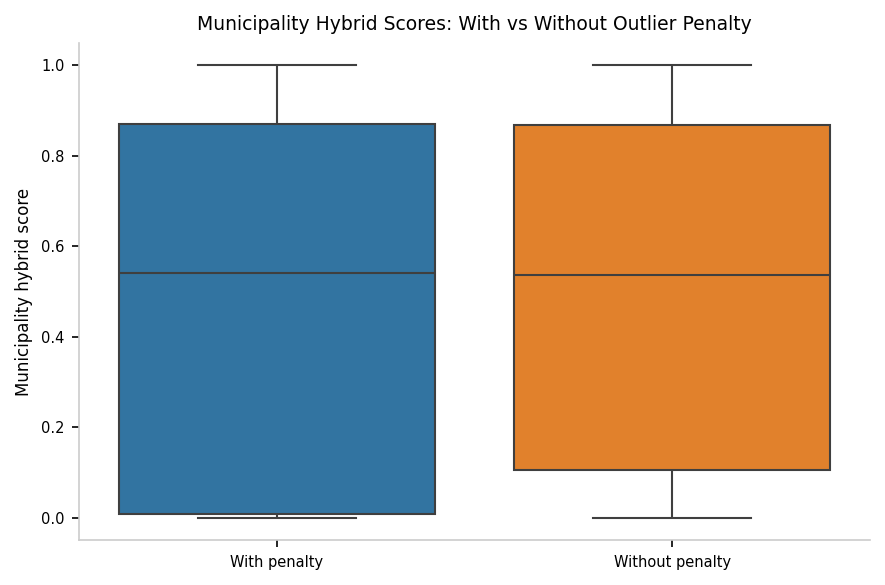

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def recompute_score_without_penalty(norm_df, weights, penalty_col):
    w = weights.copy()
    if penalty_col in w:
        w[penalty_col] = 0.0
        total = sum(w.values())
        w = {k: v / total for k, v in w.items()}

    raw = np.zeros(len(norm_df))
    for col in norm_df.columns:
        raw += norm_df[col].values * w[col]
    score = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
    return score

score_with_penalty = muni["hybrid_score"].values
score_no_penalty = recompute_score_without_penalty(
    muni_norm, muni_weights, "outlier_penalty_muni"
)

data = {
    "With penalty": score_with_penalty,
    "Without penalty": score_no_penalty,
}

plt.figure(figsize=(6, 4))
sns.boxplot(data=list(data.values()))
plt.xticks([0, 1], list(data.keys()))
plt.ylabel("Municipality hybrid score")
plt.title("Municipality Hybrid Scores: With vs Without Outlier Penalty")
plt.tight_layout()
plt.show()

In [20]:
summary = (
    muni.reset_index()[[
        "municipality",
        "n_cases",
        "avg_cycle_hours",
        "avg_processing_hours_res",
        "variant_complexity",
        "hybrid_score",
        "rank",
    ]]
    .sort_values("hybrid_score", ascending=False)
)

summary = summary.rename(columns={
    "n_cases": "case_count",
    "avg_cycle_hours": "avg_case_cycle_hours",
    "avg_processing_hours_res": "avg_resource_processing_hours",
    "variant_complexity": "structural_complexity",
    "hybrid_score": "municipality_hybrid_score",
})

display(summary)

,municipality,case_count,avg_case_cycle_hours,avg_resource_processing_hours,structural_complexity,municipality_hybrid_score,rank
2,BPIC15_3,804,1724.267544,64.611105,43.584577,1.000,1
0,BPIC15_1,810,2346.385508,106.129609,44.241975,0.870,2
4,BPIC15_5,637,2552.882832,54.468851,51.558870,0.541,3
1,BPIC15_2,310,3770.189789,65.873137,55.122581,0.008,4
3,BPIC15_4,622,2932.718776,81.202519,228.004823,0.000,5


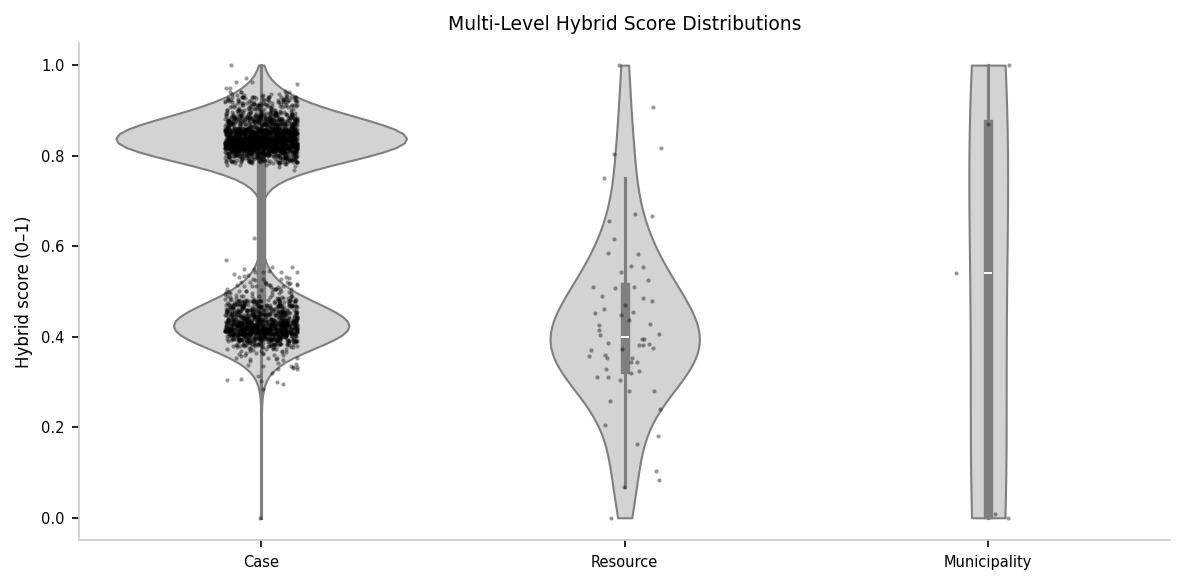

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

scores_long = pd.DataFrame({
    "score": np.concatenate([
        case_hyb["case_hybrid_score"].values,
        res_hyb["resource_hybrid_score"].values,
        muni["hybrid_score"].values,
    ]),
    "level": (
        ["Case"] * len(case_hyb)
        + ["Resource"] * len(res_hyb)
        + ["Municipality"] * len(muni)
    )
})

plt.figure(figsize=(8, 4))
sns.violinplot(
    data=scores_long,
    x="level",
    y="score",
    inner="box",
    cut=0,
    color="lightgray",
    linewidth=1.0
)
sns.stripplot(
    data=scores_long,
    x="level",
    y="score",
    color="black",
    alpha=0.4,
    size=2
)

plt.ylabel("Hybrid score (0–1)")
plt.xlabel("")
plt.title("Multi-Level Hybrid Score Distributions")
plt.tight_layout()
plt.show()